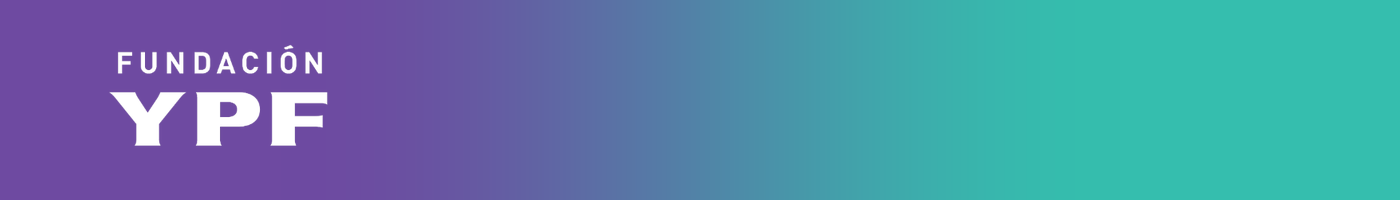

# Fundación YPF - Data Science



# Notebook 16: Regresión y clasificación

## Índice

- **Parte 0** - Repaso: carga, limpieza y preparación del dataset
- **Parte 1** - Regresión vs. clasificación: ¿qué tipo de problema tenemos?
- **Parte 2** - Regresión lineal
- **Parte 3** - Regresión logística
- **Parte 4** - Árboles de decisión
- **Parte 5** - Comparación de modelos
- **Parte 6** - Ejercicio para las salas

---

## Parte 0 - Repaso: carga, limpieza y preparación del dataset

Retomamos el dataset de expectativa de vida que ya usamos en las notebooks 12 y 13. Lo cargamos, limpiamos nombres de columnas, manejamos faltantes y separamos en entrenamiento y test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carga del dataset
try:
    df = pd.read_csv('/content/life_expectancy_data.csv')
except FileNotFoundError:
    df = pd.read_csv('life_expectancy_data.csv')

In [ ]:
print(f"Dimensiones: {df.shape}")
df.head()

In [ ]:
# Limpieza de nombres de columnas (quitar espacios al inicio y al final)
df.columns = df.columns.str.strip()
print("Columnas limpias:")
print(df.columns.tolist())

In [ ]:
# Revisión de faltantes
print("\nFaltantes por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

In [ ]:
# Eliminamos filas donde falte la variable objetivo (Life expectancy)
df = df.dropna(subset=['Life expectancy'])
print(f"\nFilas después de eliminar faltantes en Life expectancy: {len(df)}")

In [ ]:
# Completamos faltantes numéricos con la mediana
cols_numericas = df.select_dtypes(include=[np.number]).columns
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

In [ ]:
# Encoding de la variable Status (Developing / Developed)
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_status = LabelEncoder()
df['Status_encoded'] = le_status.fit_transform(df['Status'])
print(f"\nClases de Status: {le_status.classes_}")
print(f"Encoded: {le_status.transform(le_status.classes_)}")

In [ ]:
# Separación en entrenamiento y test
from sklearn.model_selection import train_test_split

In [ ]:
# Definimos las features numéricas que vamos a usar
features = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
            'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio',
            'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
            'thinness  1-19 years', 'thinness 5-9 years',
            'Income composition of resources', 'Schooling']

In [ ]:
X = df[features]

In [ ]:
print(f"\nFeatures seleccionadas: {len(features)}")
print(f"Observaciones: {len(X)}")

---

## Parte 1 - Regresión vs. clasificación: ¿qué tipo de problema tenemos?

Sobre el mismo dataset podemos plantear dos preguntas distintas:

1. **Regresión**: ¿cuántos años de expectativa de vida tiene un país? (variable continua)
2. **Clasificación**: ¿el país es "Developed" o "Developing"? (variable categórica)

La elección del tipo de problema define qué algoritmo usar, qué métrica medir y cómo interpretar los resultados.

In [ ]:
# Variable objetivo para REGRESIÓN
y_reg = df['Life expectancy']
print("Regresión: predecir Life expectancy (continua)")
print(f"  Rango: {y_reg.min():.1f} a {y_reg.max():.1f} años")
print(f"  Media: {y_reg.mean():.1f} años")

In [ ]:
# Variable objetivo para CLASIFICACIÓN
y_clf = df['Status_encoded']
print(f"\nClasificación: predecir Status (Developing=0, Developed=1)")
print(f"  Proporción clase mayoritaria: {y_clf.value_counts(normalize=True).max():.3f}")
print(f"  Este es nuestro piso de referencia para clasificación.")

In [ ]:
# Separamos para ambos problemas
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [ ]:
# Para clasificación usamos los mismos índices
y_train_clf = y_clf.loc[X_train.index]
y_test_clf = y_clf.loc[X_test.index]

In [ ]:
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

In [ ]:
# Escalado: ajustamos SOLO con train
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

In [ ]:
print("Escalado ajustado con train y aplicado a test (buena práctica de clase 8).")

---

## Parte 2 - Regresión lineal

Regresión lineal busca la recta (o hiperplano) Y = m1*x1 + m2*x2 + ... + b que minimiza el error cuadrático medio sobre los datos de entrenamiento.

**Supuestos** (repaso de la clase):
- Relación lineal entre X e Y
- Residuos con distribución normal
- Homocedasticidad (varianza constante de los residuos)
- No multicolinealidad

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

In [ ]:
# Piso de referencia para regresión
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train_scaled, y_train_reg)
y_pred_dummy = dummy_reg.predict(X_test_scaled)

In [ ]:
mae_dummy = mean_absolute_error(y_test_reg, y_pred_dummy)
r2_dummy = r2_score(y_test_reg, y_pred_dummy)
print(f"Piso de referencia (predecir la media):")
print(f"  MAE: {mae_dummy:.2f} años")
print(f"  R²:  {r2_dummy:.4f}")

In [ ]:
# Regresión lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
print(f"\nRegresión lineal:")
print(f"  MAE: {mae_lr:.2f} años")
print(f"  R²:  {r2_lr:.4f}")

In [ ]:
# Visualización: predicho vs. real
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

In [ ]:
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.4, s=15)
axes[0].plot([40, 90], [40, 90], 'r--', lw=1)
axes[0].set_xlabel('Valor real (años)')
axes[0].set_ylabel('Valor predicho (años)')
axes[0].set_title('Regresión Lineal: predicho vs. real')

In [ ]:
# Distribución de residuos
residuos = y_test_reg - y_pred_lr
axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuo (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los residuos')
axes[1].axvline(x=0, color='r', linestyle='--', lw=1)

In [ ]:
plt.tight_layout()
plt.show()

In [ ]:
print(f"\nLos 5 features con mayor peso (valor absoluto):")
coefs = pd.Series(lr.coef_, index=features).abs().sort_values(ascending=False)
print(coefs.head())

---

## Parte 3 - Regresión logística

Pese a su nombre, regresión logística es un algoritmo de **clasificación**. Usa la función sigmoide para transformar la salida de una combinación lineal en una probabilidad entre 0 y 1.

**Supuestos:**
- Linealidad entre las features y el log-odds
- Independencia de observaciones
- No multicolinealidad
- Tamaño de muestra suficiente

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

In [ ]:
# Piso de referencia para clasificación
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled, y_train_clf)
y_pred_dummy_clf = dummy_clf.predict(X_test_scaled)

In [ ]:
acc_dummy = accuracy_score(y_test_clf, y_pred_dummy_clf)
print(f"Piso de referencia (predecir la clase mayoritaria):")
print(f"  Exactitud: {acc_dummy:.3f}")

In [ ]:
# Regresión logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_scaled)

In [ ]:
acc_log = accuracy_score(y_test_clf, y_pred_log)
print(f"\nRegresión logística:")
print(f"  Exactitud: {acc_log:.3f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test_clf, y_pred_log, target_names=le_status.classes_))

In [ ]:
# Matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_scaled, y_test_clf,
    display_labels=le_status.classes_, ax=ax, cmap='Blues'
)
ax.set_title('Matriz de confusión: Regresión Logística')
plt.tight_layout()
plt.show()

In [ ]:
# Probabilidades predichas
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print(f"\nEjemplo de probabilidades predichas (primeras 10):")
print(np.round(y_proba[:10], 3))
print("Si la probabilidad es mayor a 0.5, se clasifica como 'Developed'.")

---

## Parte 4 - Árboles de decisión

Los árboles de decisión funcionan tanto para clasificación como para regresión. Hacen preguntas binarias sobre las features y dividen los datos en subgrupos cada vez más homogéneos.

**Ventajas:** interpretables, no asumen linealidad, manejan relaciones complejas.
**Riesgo:** tienden al sobreajuste si no se controlan con max_depth o min_samples.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [ ]:
# --- Árbol para CLASIFICACIÓN ---
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_scaled, y_train_clf)
y_pred_tree_clf = tree_clf.predict(X_test_scaled)

In [ ]:
acc_tree = accuracy_score(y_test_clf, y_pred_tree_clf)
print(f"Árbol de clasificación (max_depth=3):")
print(f"  Exactitud: {acc_tree:.3f}")

In [ ]:
# Visualización del árbol
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(tree_clf, feature_names=features, class_names=le_status.classes_,
          filled=True, rounded=True, ax=ax, fontsize=8)
ax.set_title('Árbol de Clasificación (max_depth=3)')
plt.tight_layout()
plt.show()

In [ ]:
# --- Árbol para REGRESIÓN ---
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train_scaled, y_train_reg)
y_pred_tree_reg = tree_reg.predict(X_test_scaled)

In [ ]:
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree_reg)
print(f"\nÁrbol de regresión (max_depth=4):")
print(f"  MAE: {mae_tree:.2f} años")
print(f"  R²:  {r2_tree:.4f}")

### Sobreajuste en árboles

Un árbol sin límite de profundidad memoriza los datos de entrenamiento. Veamos cómo cambia el rendimiento al aumentar la profundidad.

In [ ]:
# Efecto de la profundidad sobre train y test
profundidades = range(1, 21)
acc_train_list = []
acc_test_list = []

In [ ]:
for d in profundidades:
    tree_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_temp.fit(X_train_scaled, y_train_clf)
    acc_train_list.append(accuracy_score(y_train_clf, tree_temp.predict(X_train_scaled)))
    acc_test_list.append(accuracy_score(y_test_clf, tree_temp.predict(X_test_scaled)))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profundidades, acc_train_list, 'o-', label='Train', color='#7B2D8E')
ax.plot(profundidades, acc_test_list, 's-', label='Test', color='#00B4D8')
ax.axhline(y=acc_dummy, color='gray', linestyle='--', label='Piso (clase mayoritaria)')
ax.set_xlabel('Profundidad del árbol (max_depth)')
ax.set_ylabel('Exactitud')
ax.set_title('Sobreajuste: train sube, test se estanca')
ax.legend()
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

In [ ]:
print("Cuando la exactitud en train sube mucho más que en test, el modelo está memorizando.")
print("max_depth y min_samples_leaf son herramientas para controlarlo.")

---

## Parte 5 - Comparación de modelos

Reunimos los resultados de todos los modelos en una tabla para facilitar la comparación.

In [ ]:
# Tabla de comparación para CLASIFICACIÓN
print("=" * 55)
print("CLASIFICACIÓN: ¿Developing o Developed?")
print("=" * 55)
print(f"{'Modelo':<30} {'Exactitud':>10}")
print("-" * 55)
print(f"{'Piso (clase mayoritaria)':<30} {acc_dummy:>10.3f}")
print(f"{'Regresión logística':<30} {acc_log:>10.3f}")
print(f"{'Árbol de decisión (depth=3)':<30} {acc_tree:>10.3f}")
print()

In [ ]:
# Tabla de comparación para REGRESIÓN
print("=" * 55)
print("REGRESIÓN: ¿Cuántos años de expectativa de vida?")
print("=" * 55)
print(f"{'Modelo':<30} {'MAE (años)':>10} {'R²':>10}")
print("-" * 55)
print(f"{'Piso (predecir la media)':<30} {mae_dummy:>10.2f} {r2_dummy:>10.4f}")
print(f"{'Regresión lineal':<30} {mae_lr:>10.2f} {r2_lr:>10.4f}")
print(f"{'Árbol de regresión (depth=4)':<30} {mae_tree:>10.2f} {r2_tree:>10.4f}")

### Observaciones clave

- Todos los modelos superan al piso de referencia, lo cual confirma que están aprendiendo patrones reales.
- Regresión logística y el árbol de clasificación tienen rendimientos cercanos, pero el árbol es más interpretable (podemos ver las reglas de decisión).
- En regresión, la regresión lineal captura la tendencia general pero los residuos muestran que hay relaciones que no son estrictamente lineales. El árbol puede capturar relaciones no lineales, pero con riesgo de sobreajuste.
- La elección del algoritmo no es solo por el rendimiento: la interpretabilidad, los supuestos y el contexto del problema también importan.

---

## Parte 6 - Ejercicio para las salas

**Dataset:** `cancer_mamario.csv`

**Objetivo:** Predecir si un caso de cáncer mamario tuvo recurrencia o no (`class`: "recurrence-events" / "no-recurrence-events").

**Tiempo sugerido:** 40 minutos.

### Pasos

1. **Exploración** (10 min): cargar el dataset, revisar las columnas, identificar faltantes y tipos de datos. ¿Es un problema de regresión o de clasificación?

2. **Preparación** (10 min): hacer el encoding de las variables categóricas, manejar faltantes si los hay, separar en train y test.

3. **Modelado** (10 min): entrenar al menos dos modelos de los vistos en clase (regresión logística y/o árbol de decisión). Calcular el piso con DummyClassifier.

4. **Comparación** (10 min): armar una tabla con los resultados. ¿Qué modelo funcionó mejor? ¿Cómo se compara con el piso? ¿Hay sobreajuste?

### Pistas

- Las columnas de este dataset son todas categóricas (rangos de edad, tamaño de tumor, etc.), excepto `deg-malig`. Van a necesitar encoding (OrdinalEncoder o pd.get_dummies).
- Cuidado con los valores faltantes: algunas columnas pueden tener "?" en lugar de NaN.
- El dataset es chico (286 filas), así que el tamaño de muestra importa. Tengan en cuenta esto al elegir modelos y al interpretar métricas.

### Errores frecuentes a evitar

- Escalar o ajustar cualquier transformación con todo el dataset en vez de solo con train.
- No comparar contra un piso de referencia: sin piso no se sabe si el modelo aprendió algo.
- Usar un árbol sin limitar la profundidad: con un dataset chico, va a memorizar casi seguro.

In [ ]:
# Celda de trabajo para la Parte 6

In [ ]:
try:
    df_cancer = pd.read_csv('/content/cancer_mamario.csv')
except FileNotFoundError:
    df_cancer = pd.read_csv('cancer_mamario.csv')

In [ ]:
df_cancer.head()

In [ ]:
# Tu código acá:

---

## Anexo: Soluciones sugeridas de la Parte 6

*Si se quiere entregar una versión sin soluciones, borrar desde acá hasta el final del notebook.*

In [ ]:
# Carga
try:
    df_cancer = pd.read_csv('/content/cancer_mamario.csv')
except FileNotFoundError:
    df_cancer = pd.read_csv('cancer_mamario.csv')

In [ ]:
print(f"Dimensiones: {df_cancer.shape}")
print(f"\nValores únicos por columna:")
for col in df_cancer.columns:
    print(f"  {col}: {df_cancer[col].nunique()} valores")

In [ ]:
print(f"\nDistribución de la variable objetivo:")
print(df_cancer['class'].value_counts())

In [ ]:
# Reemplazar '?' por NaN y manejar faltantes
df_cancer = df_cancer.replace('?', np.nan)
print(f"\nFaltantes después de reemplazar '?':")
print(df_cancer.isnull().sum()[df_cancer.isnull().sum() > 0])

In [ ]:
# Rellenamos faltantes categóricos con la moda
for col in df_cancer.columns:
    if df_cancer[col].isnull().sum() > 0:
        df_cancer[col] = df_cancer[col].fillna(df_cancer[col].mode()[0])

In [ ]:
# Encoding de la variable objetivo
y_cancer = (df_cancer['class'] == 'recurrence-events').astype(int)
X_cancer = df_cancer.drop(columns=['class'])

In [ ]:
# Encoding de features categóricas con get_dummies
X_cancer = pd.get_dummies(X_cancer, drop_first=True)

In [ ]:
print(f"\nFeatures después de encoding: {X_cancer.shape[1]}")

In [ ]:
# Separación
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

In [ ]:
# Escalado (solo para logística, árboles no lo necesitan)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [ ]:
# Piso
dummy_c = DummyClassifier(strategy='most_frequent')
dummy_c.fit(X_train_c_scaled, y_train_c)
acc_piso = accuracy_score(y_test_c, dummy_c.predict(X_test_c_scaled))

In [ ]:
# Regresión logística
log_c = LogisticRegression(max_iter=1000, random_state=42)
log_c.fit(X_train_c_scaled, y_train_c)
acc_log_c = accuracy_score(y_test_c, log_c.predict(X_test_c_scaled))

In [ ]:
# Árbol de decisión
tree_c = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_c.fit(X_train_c, y_train_c)  # árboles no requieren escalado
acc_tree_c = accuracy_score(y_test_c, tree_c.predict(X_test_c))

In [ ]:
# Árbol sin límite (para mostrar sobreajuste)
tree_c_nolimit = DecisionTreeClassifier(random_state=42)
tree_c_nolimit.fit(X_train_c, y_train_c)
acc_tree_nolimit_train = accuracy_score(y_train_c, tree_c_nolimit.predict(X_train_c))
acc_tree_nolimit_test = accuracy_score(y_test_c, tree_c_nolimit.predict(X_test_c))

In [ ]:
print("=" * 55)
print("RESULTADOS: Clasificación de recurrencia de cáncer mamario")
print("=" * 55)
print(f"{'Modelo':<35} {'Exactitud test':>15}")
print("-" * 55)
print(f"{'Piso (clase mayoritaria)':<35} {acc_piso:>15.3f}")
print(f"{'Regresión logística':<35} {acc_log_c:>15.3f}")
print(f"{'Árbol (max_depth=3)':<35} {acc_tree_c:>15.3f}")
print(f"{'Árbol (sin límite) - train':<35} {acc_tree_nolimit_train:>15.3f}")
print(f"{'Árbol (sin límite) - test':<35} {acc_tree_nolimit_test:>15.3f}")
print()
print("El árbol sin límite memoriza el train (exactitud ~1.0) pero no mejora en test.")
print("Este dataset es chico y difícil: los modelos no superan al piso por mucho,")
print("lo que indica que las features disponibles tienen poder predictivo limitado.")
print("Esto es un resultado válido y frecuente en datos reales.")